Link Youtube: https://youtu.be/EsFdyc2_BmY

In [2]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, regularizers
from skimage.metrics import structural_similarity as ssim
import tensorflow as tf

2026-06-29 15:51:35.890749: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782748296.071198      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782748296.124103      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782748296.557180      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782748296.557215      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782748296.557217      58 computation_placer.cc:177] computation placer alr

In [3]:
path = kagglehub.dataset_download("datamunge/overheadmnist")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/datamunge/overheadmnist


In [4]:
print(path)
print(os.listdir(path))

/kaggle/input/datasets/datamunge/overheadmnist
['test-images-idx3-ubyte', 'version2', 'test-labels-idx1-ubyte', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte', 'overhead']


In [5]:
version2_path = os.path.join(path, "version2")

print(version2_path)
print(os.listdir(version2_path))

/kaggle/input/datasets/datamunge/overheadmnist/version2
['classes.csv', 'train.csv', 'test.csv', 'data', 'test', 'train', 'labels.csv']


In [6]:
train_csv = os.path.join(version2_path, "train.csv")
test_csv = os.path.join(version2_path, "test.csv")

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

print("Data awal:", df.shape)
print(df.head())

Data awal: (76690, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      6   136.0   130.0   118.0   120.0   120.0   115.0   123.0   142.0   
1      0   191.0   187.0   189.0   191.0   180.0   158.0   122.0    88.0   
2      4    50.0    77.0    90.0    85.0   149.0   115.0   121.0   134.0   
3      3   202.0   255.0   255.0   227.0   156.0   165.0   151.0   165.0   
4      8    52.0    37.0    29.0    45.0    63.0    53.0    52.0    45.0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0   137.0  ...     172.0     255.0     140.0     137.0     164.0     209.0   
1    89.0  ...      39.0      45.0      43.0      41.0      50.0      64.0   
2   141.0  ...     135.0     190.0     220.0     180.0     153.0     125.0   
3   230.0  ...     193.0     181.0     188.0     196.0     194.0     191.0   
4    37.0  ...      60.0      62.0      59.0      51.0      52.0      60.0   

   pixel781  pixel782  pixel783  pixel784  
0     

In [7]:
selected_labels = [2, 7]
ae_df = df[df["label"].isin(selected_labels)].reset_index(drop=True)

print("Shape dataset:", ae_df.shape)
print(ae_df["label"].value_counts().sort_index())

Shape dataset: (13900, 785)
label
2    5898
7    8002
Name: count, dtype: int64


In [8]:
print(df["label"].unique())
print(df["label"].value_counts())

[6 0 4 3 8 5 7 2 1 9]
label
0    8002
4    8002
1    8002
5    8002
7    8002
9    8000
3    7986
8    7586
6    7210
2    5898
Name: count, dtype: int64


In [9]:
pixel_cols = ae_df.columns.drop("label")
all_white = (ae_df[pixel_cols] == 255).all(axis=1)
print("Jumlah gambar putih:", all_white.sum())

Jumlah gambar putih: 11


In [10]:
white_df = ae_df[all_white]

print(white_df["label"].value_counts())

label
2    11
Name: count, dtype: int64


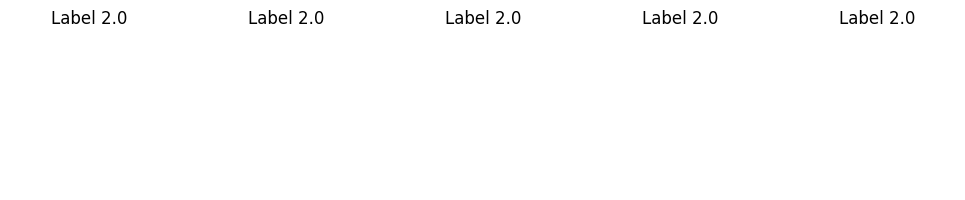

In [11]:
plt.figure(figsize=(10, 2))

for i in range(min(5, len(white_df))):
    plt.subplot(1, 5, i + 1)
    img = white_df.iloc[i].drop("label").values.reshape(28, 28)
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Label {white_df.iloc[i]['label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
pixel_cols = ae_df.columns.drop("label")
all_white = (ae_df[pixel_cols] == 255).all(axis=1)
print("Jumlah gambar putih:", all_white.sum())
ae_df = ae_df[~all_white].reset_index(drop=True)
print("Shape setelah menghapus gambar putih:", ae_df.shape)

Jumlah gambar putih: 11
Shape setelah menghapus gambar putih: (13889, 785)


In [13]:
missing_rows = ae_df[ae_df.isnull().any(axis=1)]
print("Jumlah baris dengan missing value:", len(missing_rows))
missing_rows.head()

Jumlah baris dengan missing value: 4


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
3120,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9237,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13513,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13821,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
print("Shape sebelum:", ae_df.shape)
ae_df = ae_df.dropna().reset_index(drop=True)
print("Shape sesudah:", ae_df.shape)
print("Sisa missing value:", ae_df.isnull().sum().sum())

Shape sebelum: (13889, 785)
Shape sesudah: (13885, 785)
Sisa missing value: 0


In [15]:
duplicate_rows = ae_df.duplicated().sum()
print("Jumlah duplicate rows:", duplicate_rows)

Jumlah duplicate rows: 0


In [16]:
duplicate_df = ae_df[ae_df.duplicated(keep=False)]
display(duplicate_df)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784


In [17]:
ae_df = ae_df.drop_duplicates()

In [18]:
X = ae_df.drop("label", axis=1).values
y = ae_df["label"].values

# scaling 0-1
X = X.astype("float32") / 255.0

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Min pixel:", X.min())
print("Max pixel:", X.max())

Shape X: (13885, 784)
Shape y: (13885,)
Min pixel: 0.0
Max pixel: 1.0


In [19]:
# 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (11108, 784)
X_val  : (1388, 784)
X_test : (1389, 784)


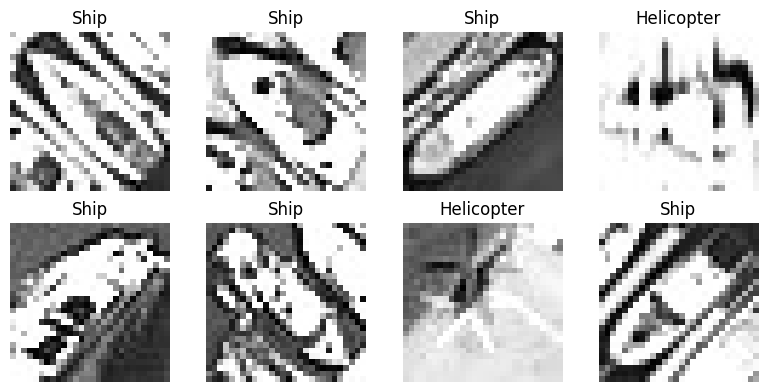

In [20]:
label_names = {
    2: "Helicopter",
    7: "Ship"
}

plt.figure(figsize=(8, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(label_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(input_img)
x = layers.MaxPooling2D((2,2), padding="same")(x)
x = layers.Flatten()(x)

x = layers.Dense(256, activation="relu")(x)
latent = layers.Dense(128, activation="relu", name="latent_128")(x)

# Decoder
x = layers.Dense(14 * 14 * 32, activation="relu")(latent)
x = layers.Reshape((14, 14, 32))(x)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(x)
decoded = layers.Conv2D(1, (3,3), activation="sigmoid", padding="same")(x)

baseline_autoencoder = models.Model(input_img, decoded)
baseline_autoencoder.compile(optimizer="adam", loss="mse")
baseline_autoencoder.summary()

I0000 00:00:1782748320.108982      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782748320.114830      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_128 (Dense)              │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,457,729 (9.38 MB)

 Trainable params: 2,457,729 (9.38 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
X_train_img = X_train.reshape(-1, 28, 28, 1)
X_val_img   = X_val.reshape(-1, 28, 28, 1)
X_test_img  = X_test.reshape(-1, 28, 28, 1)

print(X_train_img.shape)
print(X_val_img.shape)
print(X_test_img.shape)

print(X_train_img.min(), X_train_img.max())
print(X_train_img.dtype)

(11108, 28, 28, 1)
(1388, 28, 28, 1)
(1389, 28, 28, 1)
0.0 1.0
float32


Proses reshape dilakukan karena data citra disimpan dalam satu dimensi (1D) yang terdiri dari 784 nilai piksel (28 × 28 = 784). Sementara itu, arsitektur Autoencoder berbasis  memerlukan masukan dalam bentuk 2D. Oleh karena itu, data diubah dari bentuk (11108, 784) menjadi (11108, 28, 28, 1), di mana 11108 menunjukkan jumlah citra, 28 × 28 merupakan ukuran citra, dan angka 1 menunjukkan bahwa citra bersifat grayscale (satu channel). Dengan melakukan reshape, setiap nilai piksel dikembalikan ke posisi aslinya sehingga lapisan konvolusi dapat mempelajari pola spasial, seperti tepi, bentuk, dan tekstur pada gambar. Tanpa proses reshape, data tetap berbentuk vektor sehingga tidak sesuai dengan format input yang diharapkan oleh layer Conv2D dan model akan menghasilkan kesalahan (shape mismatch).

In [23]:
history_baseline = baseline_autoencoder.fit(
    X_train_img, X_train_img,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_img, X_val_img)
)

Epoch 1/20


I0000 00:00:1782748323.256985     135 service.cc:152] XLA service 0x78f93c09ad10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782748323.257028     135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782748323.257032     135 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782748323.654010     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


 48/348 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1101

I0000 00:00:1782748326.234884     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


348/348 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0670 - val_loss: 0.0513
Epoch 2/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0454 - val_loss: 0.0431
Epoch 3/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0394 - val_loss: 0.0376
Epoch 4/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0359 - val_loss: 0.0356
Epoch 5/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0336 - val_loss: 0.0334
Epoch 6/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0320 - val_loss: 0.0322
Epoch 7/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0308 - val_loss: 0.0320
Epoch 8/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0301 - val_loss: 0.0309
Epoch 9/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0292 - val_loss: 0.0303
Epoch 10/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0285 - val_loss: 0.0301
Epoch 11/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0280 - val_loss: 0.0296
Epoch 12/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0

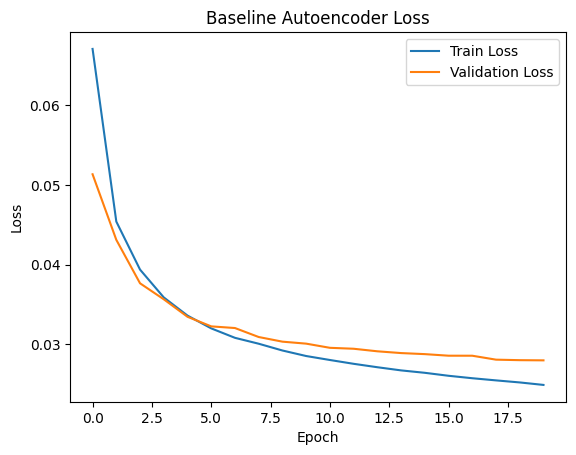

In [24]:
plt.plot(history_baseline.history["loss"], label="Train Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Autoencoder Loss")
plt.legend()
plt.show()

Model bisa mempelajari pola pada data dengan baik. Karena training loss  menurun secara konsisten dari lebih dari 0,06 pada epoch pertama menjadi sekitar 0,02 pada epoch ke-20. Penurunan tersebut menunjukkan bahwa Autoencoder semakin mampu merekonstruksi citra dengan tingkat kesalahan yang semakin kecil.

Validation loss juga mengalami penurunan yang stabil, yaitu dari sekitar 0,048 menjadi sekitar 0,024. Kondisi ini menunjukkan bahwa model tidak hanya mampu mempelajari data latih, tetapi juga dapat melakukan generalisasi dengan baik pada data validasi.

Tidak terlihat adanya indikasi overfitting yang signifikan. Meskipun setelah beberapa epoch nilai training loss lebih rendah dibandingkan validation loss, selisih keduanya tipis dan kedua kurva tetap memiliki pola penurunan yang serupa. Hal ini menunjukkan bahwa model masih memiliki kemampuan generalisasi yang baik.

Penurunan loss berlangsung sangat cepat pada beberapa epoch pertama, kemudian mulai melambat setelah sekitar epoch ke-10. Kondisi tersebut menunjukkan bahwa model mulai mencapai titik konvergensi, sehingga penambahan epoch kemungkinan hanya akan memberikan peningkatan performa yang relatif kecil.

In [25]:
reconstructed_baseline = baseline_autoencoder.predict(X_test_img)
ssim_scores = []

for i in range(len(X_test_img)):
    original = X_test_img[i].reshape(28, 28)
    reconstructed = reconstructed_baseline[i].reshape(28, 28)

    score = ssim(original, reconstructed, data_range=1.0)
    ssim_scores.append(score)

baseline_ssim= np.mean(ssim_scores)

print("Baseline SSIM:", baseline_ssim)

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Baseline SSIM: 0.6492875953236299


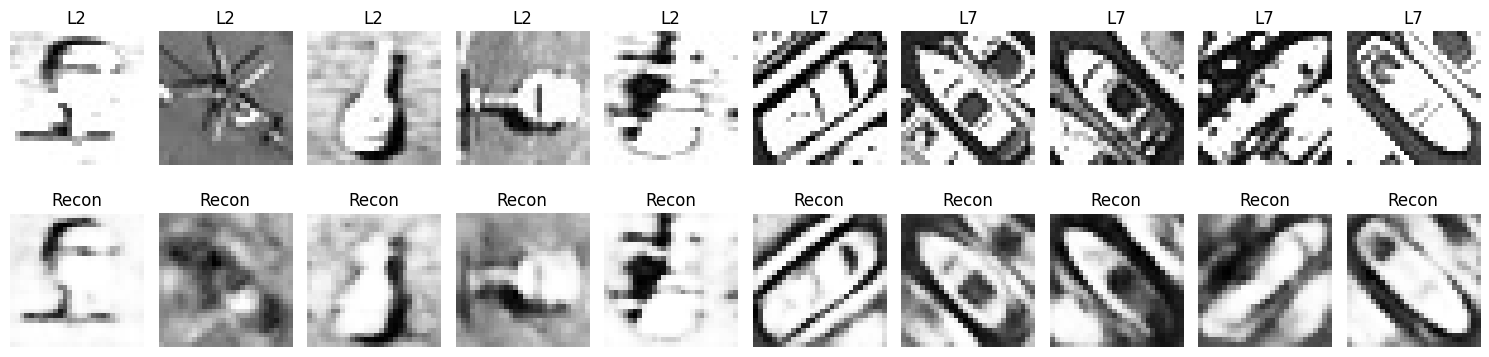

In [26]:
idx_label2 = np.where(y_test == 2)[0][:5]
idx_label7 = np.where(y_test == 7)[0][:5]

indices = np.concatenate([idx_label2, idx_label7])

plt.figure(figsize=(15, 4))

for i, idx in enumerate(indices):
    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"L{y_test[idx]}")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed_baseline[idx].reshape(28, 28), cmap="gray")
    plt.title("Recon")
    plt.axis("off")

plt.tight_layout()
plt.show()

Secara umum, Autoencoder telah mampu mempertahankan bentuk utama dari setiap objek pada kedua kelas. Pada label 2 (helicopter), bentuk badan dan baling-baling masih dapat dikenali meskipun tidak seluruh detail berhasil direkonstruksi. Demikian pula pada label 7 (ship), bentuk kapal, dek, dan posisi objek masih terlihat jelas pada hasil rekonstruksi.

Hasil rekonstruksi menunjukkan adanya penurunan tingkat ketajaman dibandingkan citra asli. Beberapa detail halus, seperti tepi objek dan tekstur di sekitar gambar, menjadi lebih kabur. Hal ini karena Autoencoder cenderung menggunakan ruang laten  untuk merepresentasikan informasi penting sehingga detail-detail kecil cenderung dihilangkan.

Rekonstruksi pada kelas ship (label 7) terlihat lebih baik dibandingkan kelas helicopter (label 2). Bentuk kapal pada sebagian besar sampel masih sangat menyerupai citra asli, sedangkan pada kelas helicopter beberapa bagian baling-baling dan badan helikopter tampak lebih kabur atau bahkan sebagian menyatu dengan latar belakang. Hal ini mengindikasikan bahwa pola visual kapal lebih mudah dipelajari oleh model dibandingkan pola helikopter yang memiliki struktur lebih kompleks.

Meskipun terdapat efek blur, tidak terlihat adanya distorsi bentuk yang signifikan. Posisi, orientasi, dan proporsi objek pada hasil rekonstruksi masih sesuai dengan citra asli. Hal ini menunjukkan bahwa Autoencoder berhasil mempelajari representasi global dari masing-masing kelas.

Perbedaan antara citra asli dan hasil rekonstruksi menunjukkan bahwa masih terdapat reconstruction error. Error tersebut terutama berasal dari hilangnya detail-detail berfrekuensi tinggi, seperti garis tipis, tekstur, dan batas objek yang tajam.

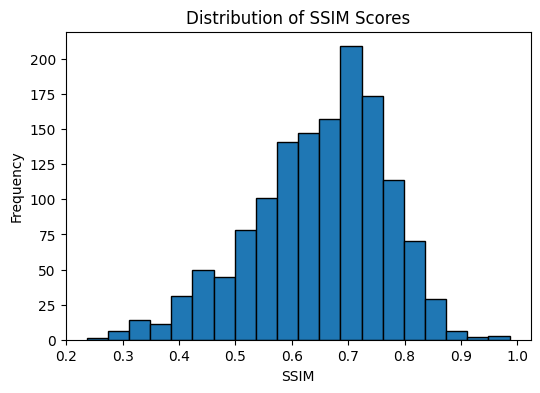

In [27]:
plt.figure(figsize=(6,4))
plt.hist(ssim_scores, bins=20, edgecolor="black")
plt.xlabel("SSIM")
plt.ylabel("Frequency")
plt.title("Distribution of SSIM Scores")
plt.show()

Sebagian besar nilai SSIM berada pada rentang sekitar 0,65 hingga 0,8, dengan puncak distribusi berada di sekitar 0,75–0,80. Hal ini menunjukkan bahwa mayoritas citra hasil rekonstruksi memiliki tingkat kemiripan struktural yang cukup tinggi terhadap citra asli.

Distribusi nilai SSIM cenderung terpusat pada nilai yang relatif tinggi, sehingga dapat disimpulkan bahwa baseline Autoencoder mampu mempertahankan struktur utama objek pada sebagian besar citra. Meskipun masih terdapat sedikit kehilangan detail, bentuk dan karakteristik utama objek tetap dapat direkonstruksi dengan baik.

Terdapat sejumlah kecil citra dengan nilai SSIM di bawah 0,50. Hal ini menunjukkan bahwa beberapa sampel memiliki kualitas rekonstruksi yang lebih rendah dibandingkan mayoritas data. 

Nilai SSIM tertinggi mencapai sekitar 0,90, yang menunjukkan bahwa beberapa citra berhasil direkonstruksi dengan sangat baik dan memiliki struktur yang hampir sama dengan citra asli. Sebaliknya, nilai terendah berada di sekitar 0,30, namun jumlah sampel pada rentang tersebut sangat sedikit sehingga tidak memengaruhi performa model secara keseluruhan.

Distribusi histogram tidak menunjukkan penyebaran yang terlalu lebar dan tidak didominasi oleh nilai SSIM yang rendah. Hal ini berarti kualitas rekonstruksi model cukup konsisten pada sebagian besar data uji.

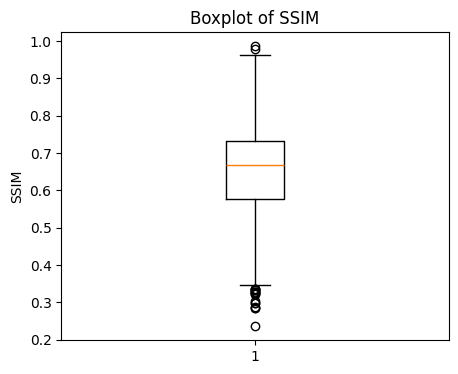

In [28]:
plt.figure(figsize=(5,4))
plt.boxplot(ssim_scores)
plt.ylabel("SSIM")
plt.title("Boxplot of SSIM")
plt.show()

Berdasarkan boxplot nilai SSIM, terlihat bahwa median SSIM berada di sekitar 0,62, yang menunjukkan bahwa sebagian besar citra hasil rekonstruksi memiliki tingkat kemiripan struktural yang cukup baik terhadap citra asli. Rentang interkuartil (IQR) berada pada kisaran sekitar 0,65 hingga 0,8, menandakan bahwa mayoritas nilai SSIM terkonsentrasi pada rentang tersebut sehingga kualitas rekonstruksi model relatif konsisten. Selain itu, terdapat beberapa outlier di bawah nilai 0,35, bahkan hingga sekitar 0,30, yang mengindikasikan bahwa sejumlah kecil citra memiliki kualitas rekonstruksi yang lebih rendah dibandingkan mayoritas data. Namun, karena jumlah outlier relatif sedikit dan sebagian besar nilai berada pada rentang yang tinggi, dapat disimpulkan bahwa baseline Autoencoder secara umum mampu mempertahankan struktur utama citra dengan baik, meskipun masih terdapat beberapa sampel yang sulit direkonstruksi secara optimal.


/tmp/ipykernel_58/1538531814.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ssim_label2, ssim_label7], labels=["Helicopter", "Ship"])


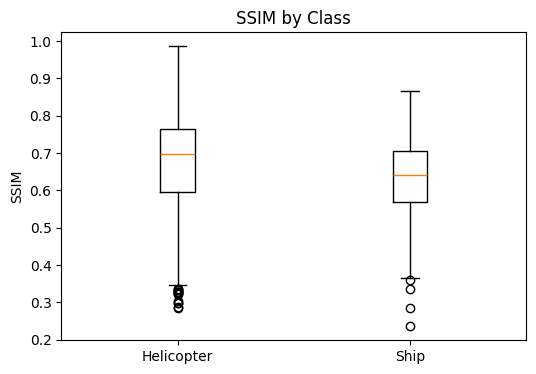

In [29]:
ssim_scores = np.array(ssim_scores)

ssim_label2 = ssim_scores[y_test == 2]
ssim_label7 = ssim_scores[y_test == 7]

plt.figure(figsize=(6,4))
plt.boxplot([ssim_label2, ssim_label7], labels=["Helicopter", "Ship"])
plt.ylabel("SSIM")
plt.title("SSIM by Class")
plt.show()

Berdasarkan boxplot SSIM untuk masing-masing kelas, terlihat bahwa kelas Helicopter memiliki nilai median SSIM yang sedikit lebih tinggi, yaitu sekitar 0,7, dibandingkan kelas Ship yang memiliki median sekitar 0,65. Hal ini berarti Autoencoder bisa merekonstruksi citra helicopter sedikit lebih baik daripada citra ship. Sebaran nilai SSIM antara kedua kelas tidak terlalu berbeda. Selain itu, kedua kelas memiliki beberapa outlier dengan nilai SSIM yang rendah, terutama pada kelas Helicopter, yang mengindikasikan bahwa terdapat beberapa citra yang lebih sulit direkonstruksi akibat variasi bentuk, orientasi, atau kompleksitas objek. Meskipun demikian, secara keseluruhan kedua kelas memiliki mayoritas nilai SSIM di atas 0,60, sehingga dapat disimpulkan bahwa baseline Autoencoder mampu mempertahankan struktur utama citra dengan baik pada kedua kelas.


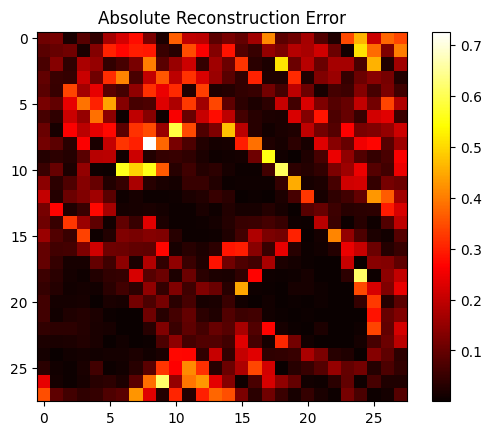

In [30]:
error = np.abs(X_test[idx].reshape(28,28) -
               reconstructed_baseline[idx].reshape(28,28))

plt.imshow(error, cmap="hot")
plt.colorbar()
plt.title("Absolute Reconstruction Error")
plt.show()

Dapat terlihat bahwa sebagian besar piksel memiliki nilai kesalahan yang rendah, ditunjukkan oleh dominasi warna gelap pada citra. Hal ini menunjukkan bahwa Autoencoder mampu merekonstruksi sebagian besar area citra dengan baik. Namun, terdapat beberapa area berwarna kuning hingga putih di tepi objek atau detail yang sering yang memiliki perubahan intensitas piksel yang tajam, sehingga lebih sulit dipelajari oleh model.

Modified 

In [31]:
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(input_img)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2), padding="same")(x)   # 14x14x64

x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2), padding="same")(x)   # 7x7x128

x = layers.Flatten()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)

latent = layers.Dense(128, activation="relu", name="latent_128")(x)

# Decoder
x = layers.Dense(7 * 7 * 128, activation="relu")(latent)
x = layers.Reshape((7, 7, 128))(x)

x = layers.Conv2DTranspose(128, (3,3), strides=2, padding="same", activation="relu")(x)  # 14x14x128
x = layers.BatchNormalization()(x)

x = layers.Conv2DTranspose(64, (3,3), strides=2, padding="same", activation="relu")(x)   # 28x28x64
x = layers.BatchNormalization()(x)

x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(x)
decoded = layers.Conv2D(1, (3,3), padding="same", activation="sigmoid")(x)

modified_autoencoder_v2 = models.Model(input_img, decoded)

modified_autoencoder_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="mse"
)

modified_autoencoder_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_128 (Dense)              │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,404,737 (16.80 MB)

 Trainable params: 4,402,945 (16.80 MB)

 Non-trainable params: 1,792 (7.00 KB)

Di Baseline autoencoder punya arsitektur yang cukup sederhana. Di bagian encoder, model cuma menggunakan satu layer Conv2D dengan 32 filter, lalu langsung dilakukan MaxPooling untuk mengecilkan ukuran gambar. Setelah itu hasilnya diubah menjadi satu dimensi menggunakan Flatten, diproses di Dense 256, lalu dikompresi menjadi latent vector berukuran 128. Di bagian decoder juga masih sederhana karena hanya menggunakan Dense, Reshape, UpSampling2D, satu Conv2D, lalu menghasilkan output melalui Conv2D dengan aktivasi sigmoid. Karena strukturnya sederhana, proses training  lebih cepat, tapi kemampuan model dalam menangkap detail gambar juga masih terbatas. Biasanya model lebih fokus mempelajari bentuk-bentuk besarnya saja, sehingga hasil rekonstruksinya kadang masih terlihat agak blur atau ada detail yang hilang.

Sementara itu, untuk modified autoencoder v2 arsitekturnya dibuat lebih dalam supaya model bisa belajar lebih banyak dari gambar. Encoder tidak lagi cuma memakai satu Conv2D, tapi ada dua layer Conv2D dengan 64 dan 128 filter. Dengan jumlah filter yang lebih banyak, model jadi bisa mengenali lebih banyak pola, mulai dari garis-garis sederhana sampai bentuk yang lebih kompleks. Selain itu proses MaxPooling juga dilakukan dua kali, jadi ukuran gambar diperkecil secara bertahap dari 28×28 menjadi 14×14, lalu menjadi 7×7. Cara ini bikin model lebih fokus menyimpan informasi yang benar-benar penting sebelum masuk ke latent space.

Selain itu ada juga BatchNormalization. Layer ini ditambahkan di beberapa bagian encoder dan decoder supaya proses training lebih stabil. Jadi perubahan nilai di setiap layer nggak terlalu ekstrem, sehingga model lebih gampang belajar dan proses konvergensinya juga biasanya lebih mulus. Selain itu, sebelum masuk ke latent vector, modified memakai Dense 512, sedangkan baseline cuma Dense 256. Artinya kapasitas model untuk memahami pola gambar jadi lebih besar sebelum akhirnya dikompresi ke ukuran 128.

Di bagian decoder, aseline menggunakan UpSampling2D untuk memperbesar ukuran gambar, sedangkan modified memakai Conv2DTranspose. Bedanya, UpSampling cuma memperbesar ukuran feature map tanpa benar-benar belajar bagaimana membentuk detail gambar. Sementara Conv2DTranspose ikut belajar selama proses training bagaimana cara mengembalikan bentuk gambar dengan lebih baik. Makanya hasil rekonstruksi dari modified biasanya lebih tajam dan lebih mirip dengan gambar aslinya.

Alasan modified lebih bagus karena kapasitas modelnya  lebih besar. Jumlah layer bertambah, filter lebih banyak, ada BatchNormalization yang bikin training lebih stabil, Dense layer lebih besar, dan proses upsampling diganti menjadi Conv2DTranspose yang lebih unggul dalam membangun kembali gambar. Semua perubahan itu membuat model lebih mampu menangkap detail penting dari gambar, jadi hasil rekonstruksinya umumnya lebih bersih, lebih jelas, dan lebih mendekati gambar asli dibandingkan baseline.


In [32]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6
    )
]

In [33]:
X_train_img = X_train.reshape(-1, 28, 28, 1)
X_val_img   = X_val.reshape(-1, 28, 28, 1)
X_test_img  = X_test.reshape(-1, 28, 28, 1)

In [34]:
history_modified_v2 = modified_autoencoder_v2.fit(
    X_train_img, X_train_img,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_img, X_val_img),
    callbacks=callbacks
)

Epoch 1/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - loss: 0.0563 - val_loss: 0.1147 - learning_rate: 5.0000e-04
Epoch 2/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0394 - val_loss: 0.0936 - learning_rate: 5.0000e-04
Epoch 3/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0344 - val_loss: 0.0497 - learning_rate: 5.0000e-04
Epoch 4/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0310 - val_loss: 0.0306 - learning_rate: 5.0000e-04
Epoch 5/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0285 - val_loss: 0.0286 - learning_rate: 5.0000e-04
Epoch 6/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0264 - val_loss: 0.0270 - learning_rate: 5.0000e-04
Epoch 7/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0248 - val_loss: 0.0254 - learning_rate: 5.0000e-04
Epoch 8/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0232 - val_loss: 0.0249 - learning_rate: 5.0000e-04
Epoch 9/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0221 - 

In [35]:
reconstructed_modified_v2 = modified_autoencoder_v2.predict(X_test_img)

ssim_scores_modified_v2 = []

for i in range(len(X_test_img)):
    original = X_test_img[i].reshape(28, 28)
    reconstructed = reconstructed_modified_v2[i].reshape(28, 28)

    score = ssim(original, reconstructed, data_range=1.0)
    ssim_scores_modified_v2.append(score)

modified_ssim_v2 = np.mean(ssim_scores_modified_v2)

print("Baseline SSIM:", baseline_ssim)
print("Modified V2 SSIM:", modified_ssim_v2)

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
Baseline SSIM: 0.6492875953236299
Modified V2 SSIM: 0.8064284887486671


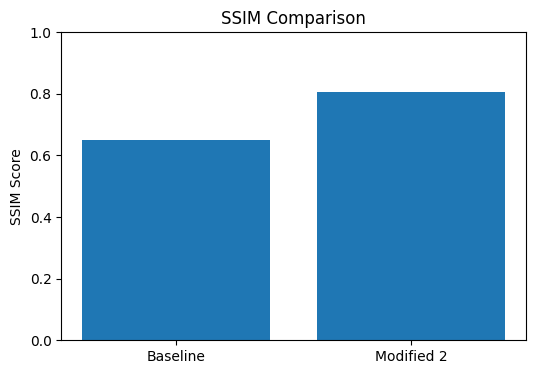

In [36]:
plt.figure(figsize=(6,4))
plt.bar(
    ["Baseline", "Modified 2"],
    [baseline_ssim,modified_ssim_v2]
)
plt.ylabel("SSIM Score")
plt.title("SSIM Comparison")
plt.ylim(0, 1)
plt.show()

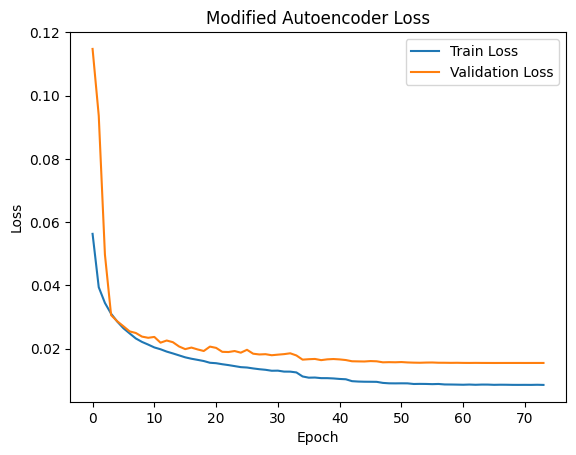

In [37]:
plt.plot(history_modified_v2.history["loss"], label="Train Loss")
plt.plot(history_modified_v2.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Modified Autoencoder Loss")
plt.legend()
plt.show()

Nilai train loss dan validation loss sama-sama mengalami penurunan yang cukup tajam pada beberapa epoch pertama. Hal ini menandakan bahwa model dengan cepat mulai mempelajari pola dasar dari data citra yang digunakan. Setelah sekitar epoch ke-10, laju penurunan loss menjadi lebih lambat hingga akhirnya cenderung stabil.

Train loss terus menurun secara konsisten hingga mencapai sekitar 0,03 pada akhir pelatihan. Sementara itu, validation loss juga mengalami penurunan hingga berada di sekitar 0,015 dan kemudian relatif konstan mulai sekitar epoch ke-50. Kondisi ini menunjukkan bahwa model telah mencapai titik konvergen, sehingga penambahan epoch setelahnya tidak lagi memberikan peningkatan performa yang signifikan pada data validasi.

Terlihat adanya selisih yang tipis antara train loss dan validation loss di akhir pelatihan berarti model masih memiliki kemampuan generalisasi yang cukup baik terhadap data yang belum pernah dilihat sebelumnya.

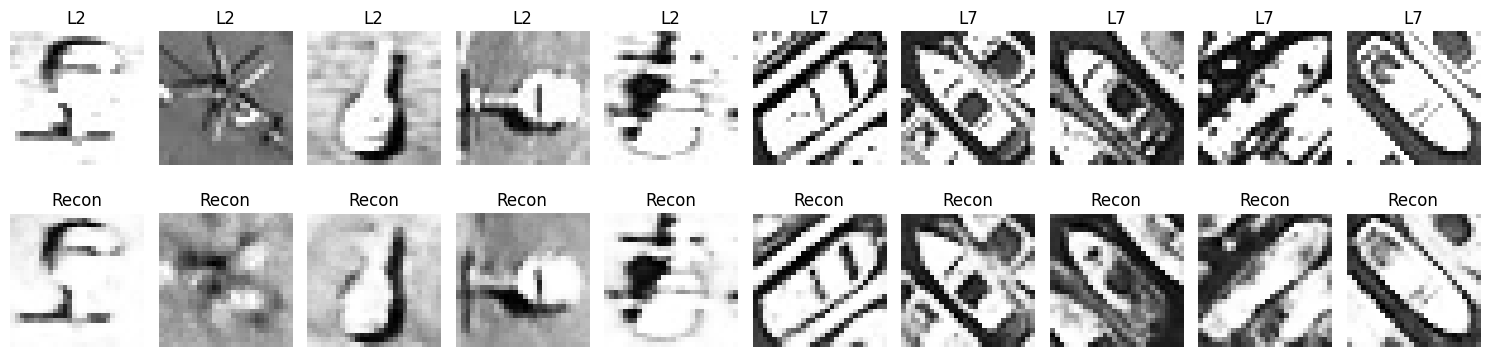

In [38]:
idx_label2 = np.where(y_test == 2)[0][:5]
idx_label7 = np.where(y_test == 7)[0][:5]

indices = np.concatenate([idx_label2, idx_label7])

plt.figure(figsize=(15, 4))

for i, idx in enumerate(indices):
    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"L{y_test[idx]}")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed_modified_v2[idx].reshape(28, 28), cmap="gray")
    plt.title("Recon")
    plt.axis("off")

plt.tight_layout()
plt.show()

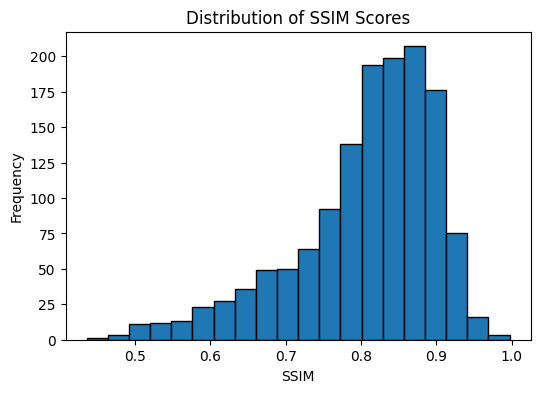

In [39]:
plt.figure(figsize=(6,4))
plt.hist(ssim_scores_modified_v2, bins=20, edgecolor="black")
plt.xlabel("SSIM")
plt.ylabel("Frequency")
plt.title("Distribution of SSIM Scores")
plt.show()

Nilai SSIM berada di antara 0,75 sampai 0,90, dengan puncak distribusi berada di sekitar 0,8–0,88. Dibandingkan dengan model baseline, distribusi nilai SSIM mengalami peningkatan. Sebagian besar citra hasil rekonstruksi memiliki tingkat kemiripan struktural yang tinggi terhadap citra asli, sehingga model mampu mempertahankan bentuk dan detail objek dengan lebih baik.

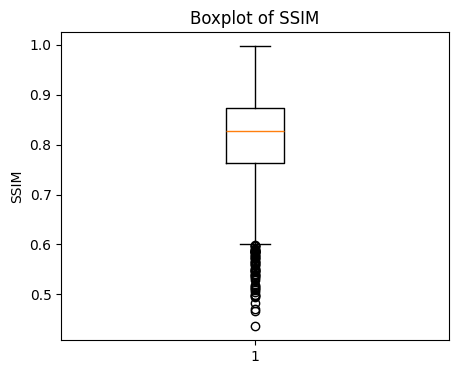

In [40]:
plt.figure(figsize=(5,4))
plt.boxplot(ssim_scores_modified_v2)
plt.ylabel("SSIM")
plt.title("Boxplot of SSIM")
plt.show()

Boxplot yang sudah modified ini terlihat bahwa median SSIM berada di sekitar 0,83, lebih tinggi dibandingkan model baseline, yang menunjukkan bahwa kualitas rekonstruksi citra mengalami peningkatan. Rentang interkuartil (IQR) berada di sekitar 0,75 ke 0,85, berarti mayoritas hasil rekonstruksi memiliki tingkat kemiripan struktural yang tinggi dan cukup konsisten. Meskipun masih terdapat beberapa outlier dengan nilai SSIM dibawah 0,6, jumlahnya relatif sedikit dibandingkan keseluruhan data sehingga tidak memberikan pengaruh yang signifikan terhadap performa model. Selain itu, nilai SSIM maksimum hampir mencapai 1,0, yang menunjukkan bahwa beberapa citra berhasil direkonstruksi dengan kualitas yang sangat mendekati citra asli. 


/tmp/ipykernel_58/2956371829.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ssim_label2, ssim_label7], labels=["Helicopter", "Ship"])


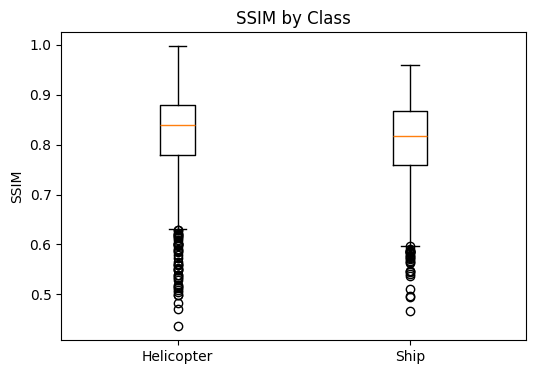

In [41]:
ssim_scores_modified_v2 = np.array(ssim_scores_modified_v2)
ssim_label2 = ssim_scores_modified_v2[y_test == 2]
ssim_label7 = ssim_scores_modified_v2[y_test == 7]

plt.figure(figsize=(6,4))
plt.boxplot([ssim_label2, ssim_label7], labels=["Helicopter", "Ship"])
plt.ylabel("SSIM")
plt.title("SSIM by Class")
plt.show()

Kedua kelas mengalami peningkatan kualitas rekonstruksi dibandingkan model baseline. Kelas5Helicopter memiliki median SSIM sekitar 0,85, sedikit lebih tinggi dibandingkan kelas Ship. Sebaran nilai SSIM pada kedua kelas juga relatif serupa dengan rentang interkuartil yang tidak terlalu lebar, menandakan bahwa kualitas rekonstruksi pada masing-masing kelas cukup konsisten. Meskipun masih terdapat beberapa outlier dengan nilai SSIM yang lebih rendah, jumlahnya relatif sedikit dibandingkan keseluruhan data sehingga tidak memengaruhi performa model secara signifikan. Selain itu, nilai SSIM maksimum pada kelas Helicopter mencapai hampir 1,0, dan pada kelas Ship hampir 0,96, yang berarti beberapa citra pada kedua kelas berhasil direkonstruksi dengan kualitas yang sangat mendekati citra asli.

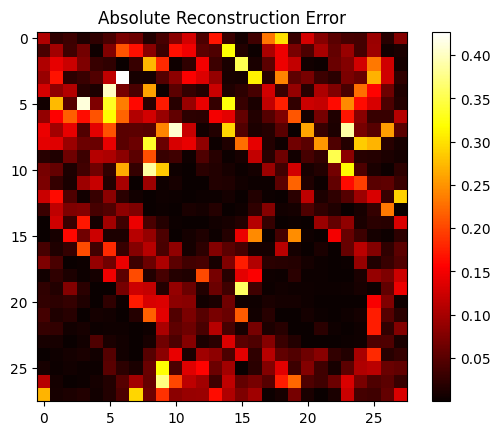

In [42]:
error = np.abs(X_test[idx].reshape(28,28)-reconstructed_modified_v2[idx].reshape(28,28))

plt.imshow(error, cmap="hot")
plt.colorbar()
plt.title("Absolute Reconstruction Error")
plt.show()

Sebagian besar piksel memiliki nilai kesalahan yang rendah, yang ditunjukkan oleh dominasi warna gelap pada citra. Dibandingkan dengan model baseline,disini kesalahan lebih minimum. Meskipun masih terdapat beberapa titik dengan nilai error yang relatif tinggi, titik-titik tersebut tersebar pada area tertentu dan jumlahnya sedikit.